#WEEK 7: ENSEMBLE METHODS ASSIGNMENT
# Random Forest & Gradient Boosting

In [ ]:
# 1. Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Load your actual preprocessed Ames Housing data
# (Replace the path below with the actual path to your CSV file)
df = pd.read_csv('/content/drive/MyDrive/UzmaFatima_ML_Internship/train.csv')

# Create the 'AboveMedian' target variable based on 'SalePrice'
median_price = df['SalePrice'].median()
df['AboveMedian'] = (df['SalePrice'] >= median_price).astype(int)

# 3. Separate your features and your target variable
X = df.drop(columns=['SalePrice', 'AboveMedian'])
y = df['AboveMedian']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

In [ ]:
# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding to both X_train and X_test
# We use pd.get_dummies and ensure that both sets have the same columns after encoding
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - this is crucial if some categories are present in train but not test, or vice-versa
common_cols = list(set(X_train_encoded.columns) & set(X_test_encoded.columns))
X_train_encoded = X_train_encoded[common_cols]
X_test_encoded = X_test_encoded[common_cols]

print(f"Shape of X_train after encoding: {X_train_encoded.shape}")
print(f"Shape of X_test after encoding: {X_test_encoded.shape}")


Shape of X_train after encoding: (1168, 202)
Shape of X_test after encoding: (292, 202)


Now that the data is numerically encoded, we can re-run the Decision Tree Baseline with 5-fold cross-validation.

In [ ]:
# Train a single DecisionTreeClassifier baseline and record 5-fold cross-val accuracy
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_cv_scores = cross_val_score(dt_baseline, X_train_encoded, y_train, cv=5)
dt_mean_acc = dt_cv_scores.mean()
dt_std_acc = dt_cv_scores.std()

print(f"Decision Tree Baseline 5-Fold CV Accuracy (after encoding): {dt_mean_acc:.4f} (+/- {dt_std_acc:.4f})")


Decision Tree Baseline 5-Fold CV Accuracy (after encoding): 0.8647 (+/- 0.0192)


## Random Forest Classifier

Train a Random Forest Classifier and compare its performance to the Decision Tree baseline. We will use 5-fold cross-validation to assess its accuracy.

In [ ]:
# Train a RandomForestClassifier and record 5-fold cross-val accuracy
rf_classifier = RandomForestClassifier(random_state=42)
rf_cv_scores = cross_val_score(rf_classifier, X_train_encoded, y_train, cv=5, n_jobs=-1)
rf_mean_acc = rf_cv_scores.mean()
rf_std_acc = rf_cv_scores.std()

print(f"Random Forest Classifier 5-Fold CV Accuracy: {rf_mean_acc:.4f} (+/- {rf_std_acc:.4f})")

# Compare with Decision Tree Baseline
print(f"\nDecision Tree Baseline Mean CV Accuracy: {dt_mean_acc:.4f}")
print(f"Random Forest Classifier Mean CV Accuracy: {rf_mean_acc:.4f}")
if rf_mean_acc > dt_mean_acc:
    print("Random Forest performed better than the Decision Tree baseline.")
elif rf_mean_acc < dt_mean_acc:
    print("Random Forest performed worse than the Decision Tree baseline.")
else:
    print("Random Forest performed similarly to the Decision Tree baseline.")

Random Forest Classifier 5-Fold CV Accuracy: 0.9195 (+/- 0.0120)

Decision Tree Baseline Mean CV Accuracy: 0.8647
Random Forest Classifier Mean CV Accuracy: 0.9195
Random Forest performed better than the Decision Tree baseline.


### Plot Top 10 Features by Feature Importance (Random Forest)

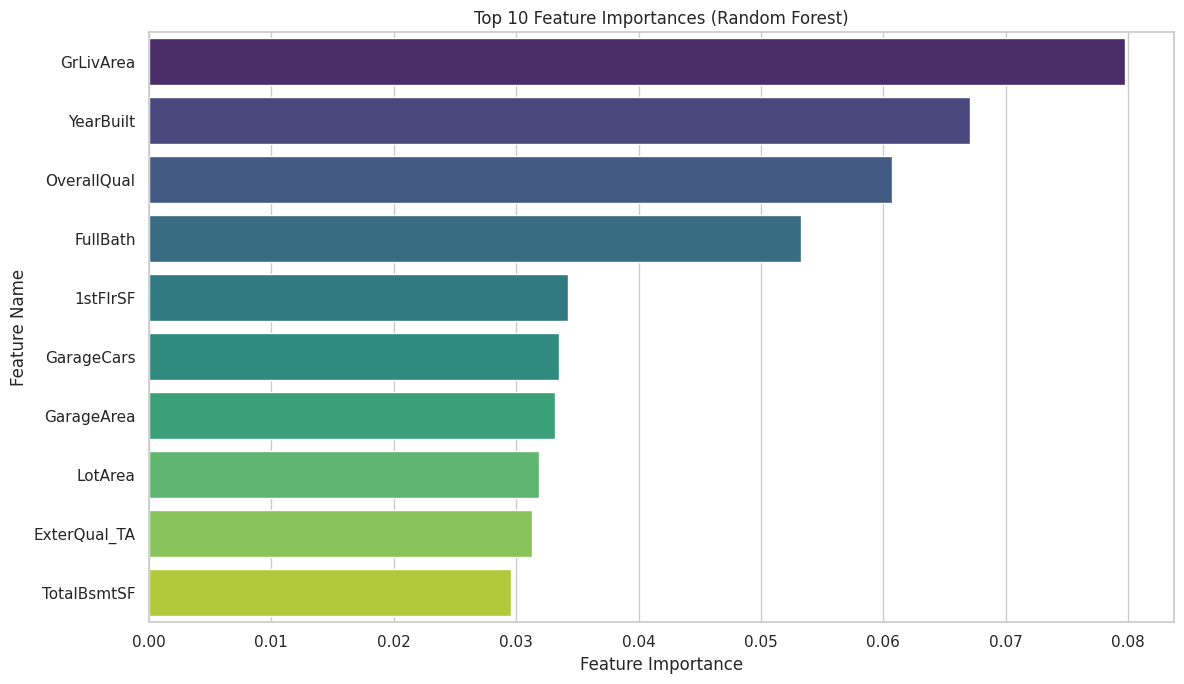

In [ ]:
rf_classifier.fit(X_train_encoded, y_train)
feature_importances = rf_classifier.feature_importances_
feature_names = X_train_encoded.columns

# Create a Series for easy sorting
importance_df = pd.Series(feature_importances, index=feature_names)

# Sort and get top 10 features
top_10_features = importance_df.nlargest(10)

# Plotting
fig = plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_features.values, y=top_10_features.index, palette='viridis', hue=top_10_features.index, legend=False)
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## Implement Gradient Boosting Classifier
Train a GradientBoostingClassifier using `X_train_encoded` and `y_train`, and evaluate its performance using 5-fold cross-validation. Compare its accuracy to the previously calculated Decision Tree and Random Forest mean accuracies.


**Reasoning**:
Impute missing values in `X_train_encoded` and `X_test_encoded` using the mean strategy, as `GradientBoostingClassifier` does not handle NaN values natively.



In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train_encoded_imputed = imputer.fit_transform(X_train_encoded)
X_test_encoded_imputed = imputer.transform(X_test_encoded)

# Convert back to DataFrame, keeping column names
X_train_encoded_imputed = pd.DataFrame(X_train_encoded_imputed, columns=X_train_encoded.columns, index=X_train_encoded.index)
X_test_encoded_imputed = pd.DataFrame(X_test_encoded_imputed, columns=X_test_encoded.columns, index=X_test_encoded.index)

gb_classifier = GradientBoostingClassifier(random_state=42)
gb_cv_scores = cross_val_score(gb_classifier, X_train_encoded_imputed, y_train, cv=5, n_jobs=-1)
gb_mean_acc = gb_cv_scores.mean()
gb_std_acc = gb_cv_scores.std()

print(f"Gradient Boosting Classifier 5-Fold CV Accuracy: {gb_mean_acc:.4f} (+/- {gb_std_acc:.4f})")

# Compare with previous models
print(f"\nDecision Tree Baseline Mean CV Accuracy: {dt_mean_acc:.4f}")
print(f"Random Forest Classifier Mean CV Accuracy: {rf_mean_acc:.4f}")
print(f"Gradient Boosting Classifier Mean CV Accuracy: {gb_mean_acc:.4f}")


# Determine the best performing model among the three
best_model_name = "Decision Tree Baseline"
best_accuracy = dt_mean_acc

if rf_mean_acc > best_accuracy:
    best_accuracy = rf_mean_acc
    best_model_name = "Random Forest Classifier"

if gb_mean_acc > best_accuracy:
    best_accuracy = gb_mean_acc
    best_model_name = "Gradient Boosting Classifier"

print(f"\nThe best performing model so far is: {best_model_name} with a mean CV accuracy of {best_accuracy:.4f}")

Gradient Boosting Classifier 5-Fold CV Accuracy: 0.9075 (+/- 0.0161)

Decision Tree Baseline Mean CV Accuracy: 0.8647
Random Forest Classifier Mean CV Accuracy: 0.9195
Gradient Boosting Classifier Mean CV Accuracy: 0.9075

The best performing model so far is: Random Forest Classifier with a mean CV accuracy of 0.9195


## Hyperparameter Tuning for Random Forest


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [5, 10, None]  # None means unlimited depth
}
print("Parameter grid defined successfully.")

Parameter grid defined successfully.


In [ ]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=1)

# Fit GridSearchCV to the imputed training data
grid_search.fit(X_train_encoded_imputed, y_train)

# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Store the best estimator
best_rf_model = grid_search.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters found: {'max_depth': 10, 'max_features': 'log2', 'n_estimators': 300}
Best cross-validation accuracy: 0.9238


### Tuned Random Forest Model Performance

After hyperparameter tuning using GridSearchCV, the optimal parameters for the RandomForestClassifier were found to be:
- `max_depth`: 10
- `max_features`: 'log2'
- `n_estimators`: 300

The best cross-validation accuracy achieved with these parameters is **0.9238**.

In [ ]:
if grid_search.best_score_ > gb_mean_acc:
    final_best_model = best_rf_model
    final_best_model_name = "Tuned Random Forest"
else:
    # Re-train gb_classifier on the full imputed training data before using it for prediction
    # to ensure it's comparable to the best_rf_model which is already fitted on full data through GridSearchCV
    final_best_model = GradientBoostingClassifier(random_state=42) # Initialize again
    final_best_model.fit(X_train_encoded_imputed, y_train) # Fit on full data
    final_best_model_name = "Gradient Boosting Classifier"

# Make predictions on the test set using the final best model
y_pred = final_best_model.predict(X_test_encoded_imputed)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

print(f"The overall best performing model is: {final_best_model_name}")
print(f"Final Test Set Accuracy for the {final_best_model_name}: {test_accuracy:.4f}")

The overall best performing model is: Tuned Random Forest
Final Test Set Accuracy for the Tuned Random Forest: 0.9521


## Summary:

### Data Analysis Key Findings

*   **Decision Tree Baseline**: Mean 5-fold cross-validation accuracy of 0.8647.
*   **Random Forest Classifier**: Mean 5-fold cross-validation accuracy of 0.9195, outperforming the Decision Tree baseline.
*   **Gradient Boosting Classifier**: Mean 5-fold cross-validation accuracy of 0.9075.
*   **Tuned Random Forest Classifier**: Achieved a best 5-fold cross-validation accuracy of 0.9238 with optimal parameters: `{'max_depth': 10, 'max_features': 'log2', 'n_estimators': 300}`.
*   The **Tuned Random Forest** was identified as the overall best performing model.
*   The final accuracy of the **Tuned Random Forest** on the unseen test set was **0.9521**.


